# Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("tableau-colorblind10")
sns.set_palette("colorblind")

In [2]:
df=pd.read_csv(r"../data/hour.csv")
df["dteday"]=df["dteday"].astype("datetime64[ns]")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-null  int64

## Infos über den Datensatz
### Hintergrundgeschichte

###

### Features und Featureerklärung
|Feature| Explanation| Übersetzung          | Datatype |
|---|---|----------------------|----------|
|instant| record index| Index                | int      |
|dteday| date | Datum                | str      |
|season| season <br> 1: spring <br> 2: summer <br> 3: fall<br> 4: winter) | Jahreszeit           | int      |
|yr| year <br> 0: 2011 <br> 1: 2012) | Jahr                 | int      |
|mnth| month (1 to 12) | Monat                | int      |
|hr| hour (0 to 23)  | Stunde               | int      |
|holiday| weather the day is a holiday (1) or not (0) according to [http://dchr.dc.gov/page/holiday-schedule](http://dchr.dc.gov/page/holiday-schedule)| Feiertag             | int      |
|weekday| day of the week| Wochentag            | int      |
|workingday| weather the day is a workingday (1) or weekend/holiday (0) | Arbeitstag/Ruhetag   | int      |
|weathersit| weathersituation <br> 1: Clear, few clouds, partly cloudy <br> 2: Mist + Cloudy, Mist + Broken Clouds, Mist + Few Clouds, Mist <br> 3: Light snow, Light rain + Thunderstorm + Scattered clouds, Light rain + Scatterd clouds <br> 4: Heavy rain + ice pallets + thunderstom + mist, Snow + fog | Wettersituation      | int      |
|temp| normalized temperature in celcius. values are divided to 41 (max) | Temperatur           | float    |
|atemp|normalized feeling temperature in celcius. values are divide to 50 (max)| gefühlte Temperatur  | float    |
|hum|normalized humidity. values are divided to 100 (max)| Feuchtigkeit         | float    |
|windspeed|normalized windspeed. values are divided to 67 (max) | Windgeschwindigkeit  | float    |
|casual|count of casual users| Nutzer ohne Konto    | int      |
|registered| count of registered users| Nutzer mit Konto     | int      |
|cnt|count of total users| Anzahl der Nutzer| int      |

In [3]:
df=df.drop(columns=["instant"])

### Korrelationsmatrix

<Axes: >

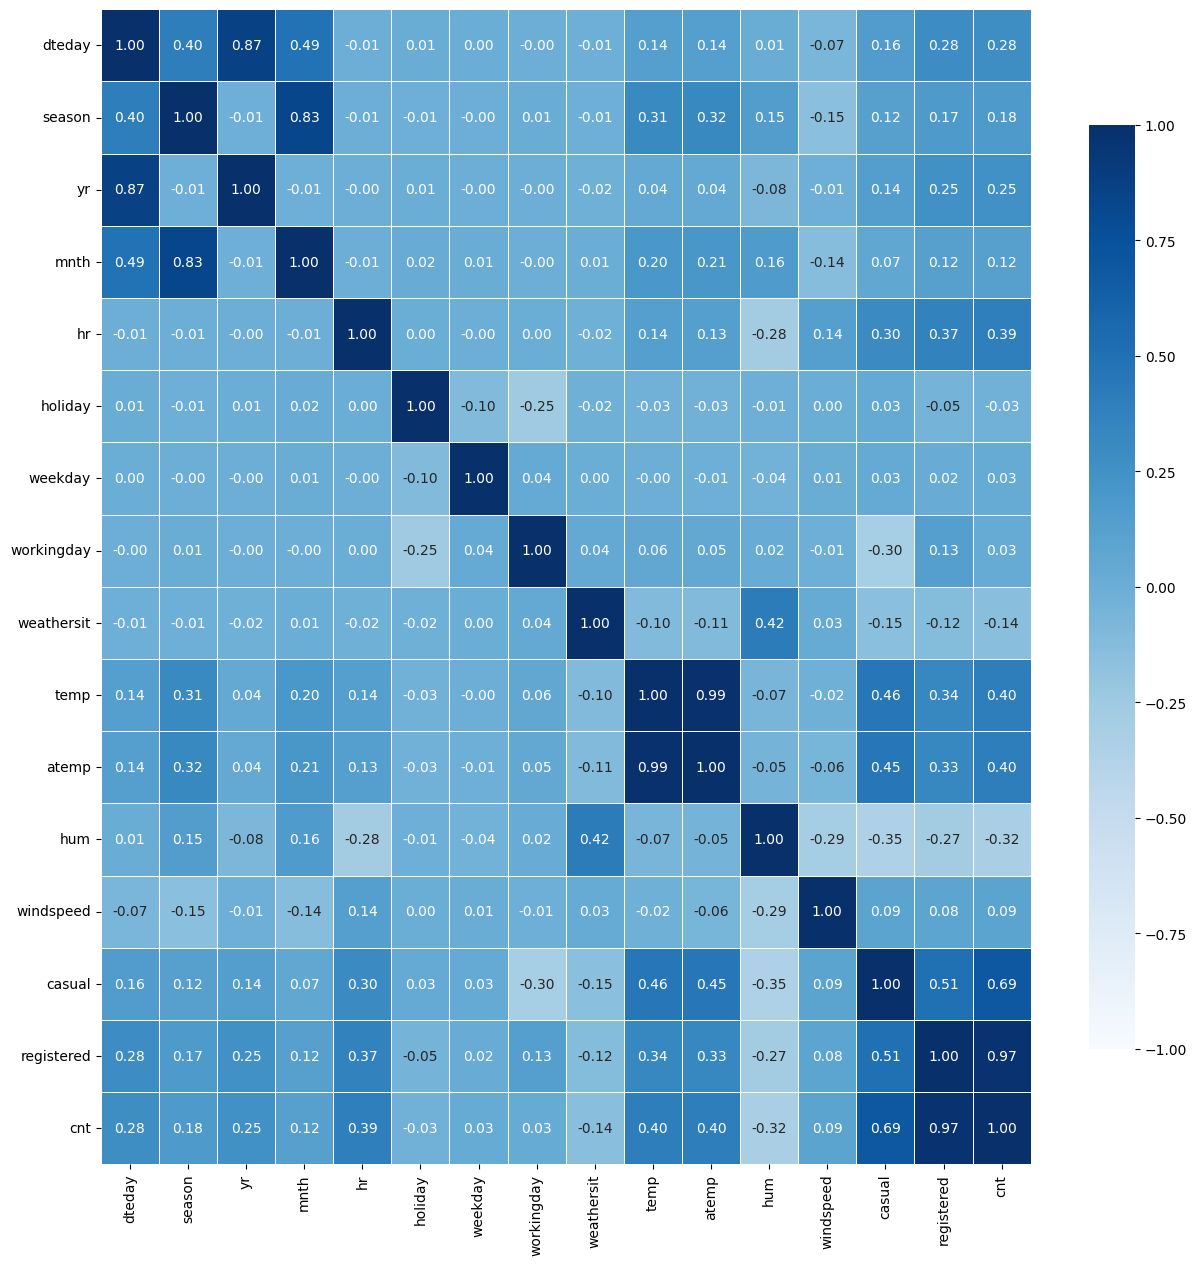

In [4]:
corr_matrix=df.corr()
plt.figure(figsize=(15,15))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    cbar_kws={'shrink': .8}
)

#### Interpretation
Die stärksten positiven Korrelationen mit cnt, der Anzahl der ausgeliehenen Fahrräder sind registered (0,97) und casual (0,69), da beide Nutzergruppen, registrierte und nicht-registrierte Nutzer die Anzahl aller Ausleihen bilden. Inhaltlich interessanter ist, dass die Temperatur und die gefühlte Temperatur (temp/atemp ≈ 0,40) und Tagesstunde (hr ≈ 0,39) den größten Einfluss haben. Negativ korrelieren vor allem Luftfeuchtigkeit (−0,32) sowie Wettersituation (−0,14). Schlechteres Wetter führt hierbei zu weniger Ausleihungen. Workingday, weekday und holiday korrelieren kaum mit der Anzahl, was darauf hindeutet, dass der Wochentag allein nicht entscheidend ist und die Tageszeit hier eine wichtigere Rolle spielt.

### Anzahl von Fahrrädern nach Jahreszeit

Text(0.5, 1.0, 'Anzahl von Fahrrädern nach Jahreszeit')

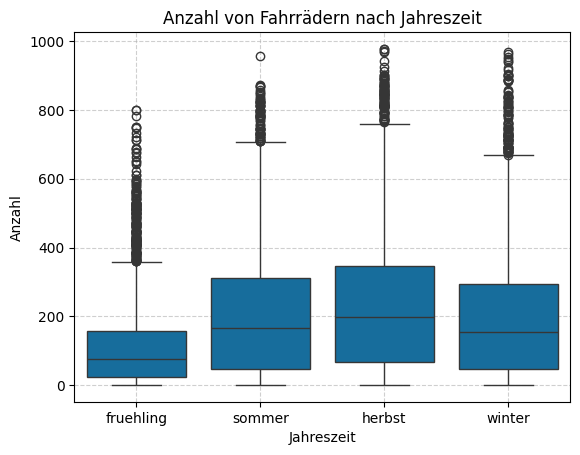

In [5]:
season_map = {1: 'fruehling', 2: 'sommer', 3: 'herbst', 4: 'winter'}
df['season'] = df['season'].map(season_map)
sns.boxplot(data=df,
            x='season',
            y='cnt',
            order=['fruehling', 'sommer', 'herbst', 'winter'])
plt.grid(True,
         linestyle='--',
         alpha=0.6
         )
plt.xlabel("Jahreszeit")
plt.ylabel("Anzahl")
plt.title("Anzahl von Fahrrädern nach Jahreszeit")

#### Interpretation
Mit einem Mittelwert von ca. 235 werden im Herbst die meisten Fahrräder ausgeliefert, gefolgt von Sommer mit ca. 210 Fahrrädern und dem Winter mit ca. 200 Fahrrädern. Auf dem letzten Platz liegt der Frühling mit ca. 110 Fahrrädern. Die Hohen Abweichungen lassen sich über saisonale Änderungen erklären, während die niedrigen Zahlen im Frühling sich damit erklären lassen, dass die ersten Monate des Jahres die kühlsten sind.  

### Anzahl von Fahrrädern je nach Wettersituation

Text(0.5, 1.0, 'Count at Weather')

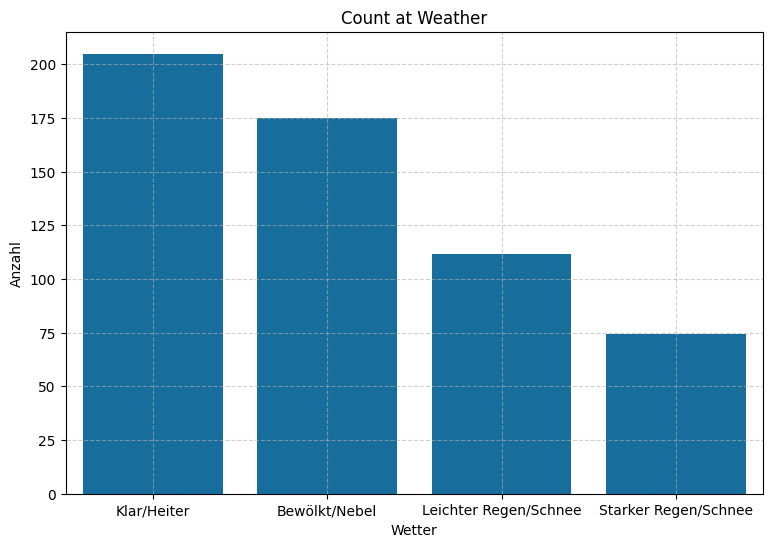

In [6]:
weather_map = {1: 'Klar/Heiter',
               2: 'Bewölkt/Nebel',
               3: 'Leichter Regen/Schnee',
               4: 'Starker Regen/Schnee'
               }
df['weather'] = df['weathersit'].map(weather_map)
plt.figure(figsize=(9,6))
sns.barplot(data=df,
            x='weather',
            y='cnt',
            errorbar=None,
            )
plt.grid(True,
         linestyle='--',
         alpha=0.6
         )
plt.xlabel("Wetter")
plt.ylabel("Anzahl")
plt.title("Anzahl nach Wettersituation")

#### Interpretation
Im Diagramm erkennt man ein Zusammenhang zwischen Wetter und Ausleihen. Je besser das Wetter, desto mehr Fahrräder werden ausgeliehen. Bei klarem Wetter liegt die Anzahl der ausgeiehenen Fahrräder bei ca. 205 Räder pro Stunde, während bei Bewölkung und Nebel ca. 175 Fahrräder ausgeliehen werden, bei leichtem Regen/Schnee nur noch ca. 112 und bei starkem Regen und Schnee lediglich ca. 74 Fahrräder ausgeliehen werden. 

### Anzahl von Fahrrädern je nach Tagesart

Text(0.5, 1.0, 'Anzahl je nach Tagesart')

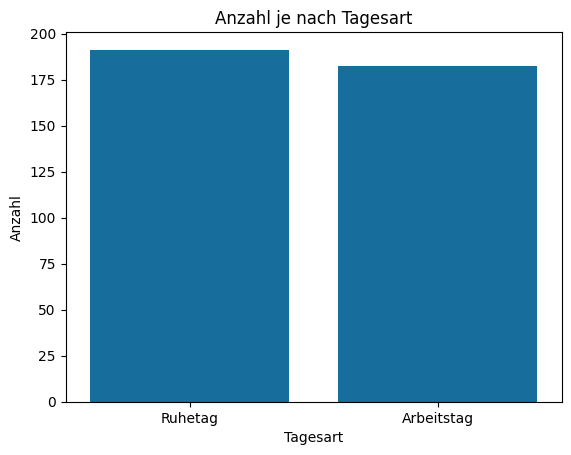

In [13]:
workingday_map = {0: 'Ruhetag', 1: 'Arbeitstag'}
df_sample = df.sample(frac=0.05,
                      random_state=42
                      )
df_sample['daykind'] = df_sample['workingday'].map(workingday_map)
sns.barplot(data=df_sample,
            x='daykind',
            y='cnt',
            errorbar=None,
            )
plt.xlabel("Tagesart")
plt.ylabel("Anzahl")
plt.title("Anzahl je nach Tagesart")

#### Interpretation
Der Unterschied zwischen Werktagen mit ca. 193 Ausleihungen pro Stunde und Wochenende bzw. Feiertagen mit ca. 181 Ausleihungen pro Stunde ist überraschend gering. Das bedeutet, dass Fahrräder an beiden Tagesarten ähnlich oft genutzt werden, allerdings aus vermutlich unterschiedlichen Gründen.

### Anzahl von Fahrrädern pro Monat

Text(0.5, 1.0, 'Anzahl pro Month')

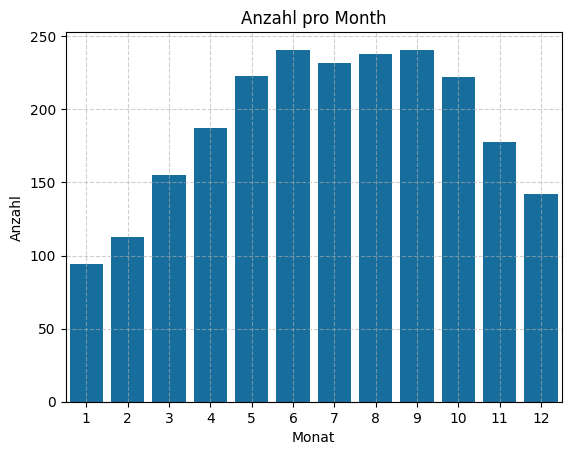

In [8]:
sns.barplot(
    data=df,
    x='mnth',
    y='cnt',
    errorbar=None,
    )
plt.xlabel("Monat")
plt.ylabel("Anzahl")
plt.grid(True,
         linestyle='--',
         alpha=0.6
         )
plt.title("Anzahl pro Month")

#### Interpretation
Die Nachfrage folgt einem saisonalen Verlauf. Die Anzahl der ausgeliehenen Fahrräder ist im Januar bei ca. 94 und steigt in den folgenden Monaten bis zum Sommer. Die Spitze wird in den Monaten zwischen Juni und September erreicht, hier liegt die Anzahl der 240 ausgeliehen Fahrrädern. In den Herbst- und Wintermonaten sinken die Anzahl der ausgeliehenen Fahrräder wieder.

### Vergleich der Anzahl der Fahrräder an Werktagen/Ruhetagen bei einer bestimmten Temperatur

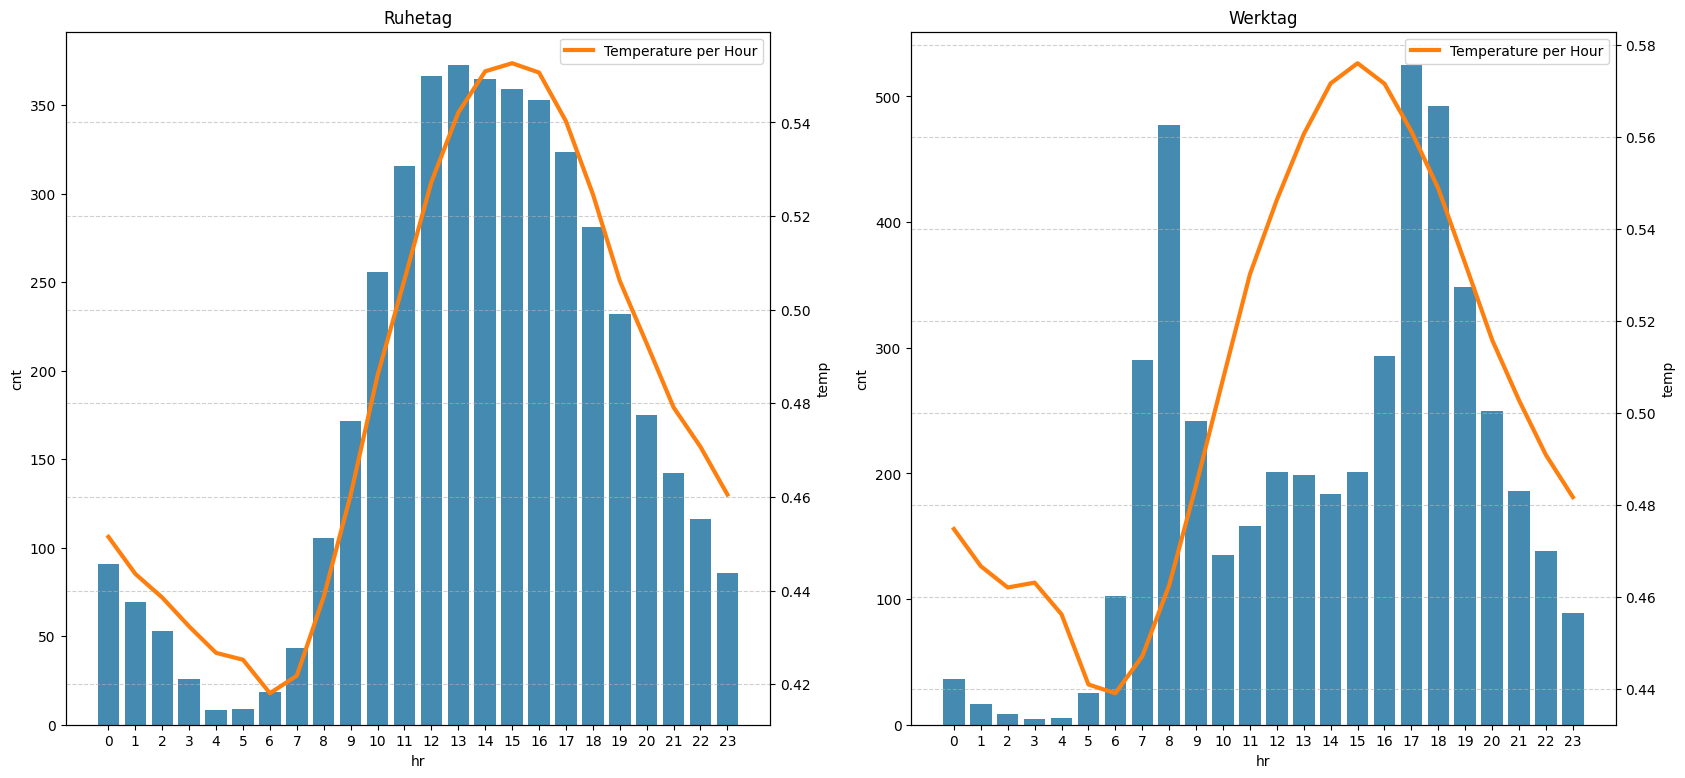

In [9]:
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(20, 9))
sns.barplot(
    data=df[df["workingday"]==0],
    x='hr',
    y='cnt',
    alpha=0.8,
    errorbar=None,
    ax=ax1,
)
plt.title("Werktag")
ax2=ax1.twinx()
sns.lineplot(
    data=df[df["workingday"]==0],
    x='hr',
    y='temp',
    color='#ff7f0e',
    errorbar=None,
    ax=ax2,
    linewidth=3,
    label='Temperature per Hour'
)
plt.grid(True, linestyle='--', alpha=0.6)

sns.barplot(
    data=df[df["workingday"]==1],
    x='hr',
    y='cnt',
    alpha=0.8,
    errorbar=None,
    ax=ax3,
)
plt.title("Ruhetag")
ax4=ax3.twinx()
sns.lineplot(
    data=df[df["workingday"]==1],
    x='hr',
    y='temp',
    color='#ff7f0e',
    errorbar=None,
    ax=ax4,
    linewidth=3,
    label='Temperature per Hour'
)
plt.grid(True,
         linestyle='--',
         alpha=0.6
         )

#### Interpretation

**Ruhetag** <br>
Eine gleichmäßige Verteilung zwischen 10 Uhr und 17 Uhr mit dem Maximum um die Mittagszeit lässt vermuten, dass die Fahrräder für Freizeitaktivitäten verwendet werden. Die Kurve korreliert mit der Temperatur mit einigen Abweichungen.

**Werktag** <br>
Zwei Spitzen gegen 8 Uhr und 17 Uhr lassen auf Pendlerverkehr schließen, die Temperaturkurve korreliert jedoch kaum mit den Spitzen.


### Anzal der Casual (nicht registrierten) und Registred (registrierten) Users pro Stunde

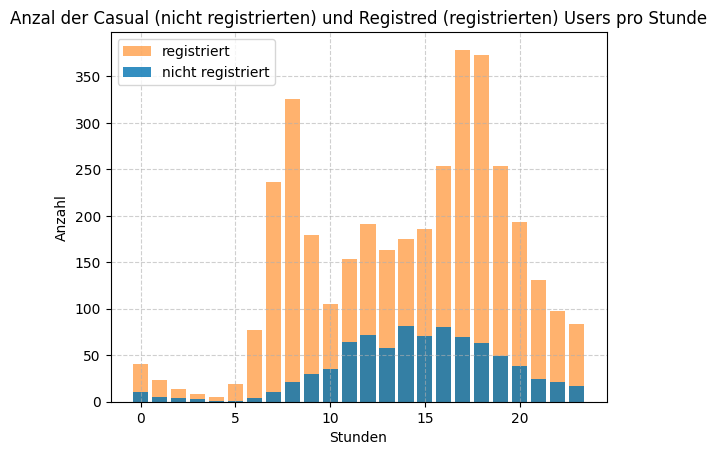

In [10]:
data_to_plot = df_sample.groupby('hr')[['casual', 'registered']].mean()
plt.bar(
    data_to_plot.index,
    data_to_plot['registered'],
    color='#ff7f0e',
    label='registriert',
    alpha=0.6
)
plt.bar(data_to_plot.index,
        data_to_plot['casual'],
        label='nicht registriert',
        alpha=0.8
        )
plt.xlabel("Stunden")
plt.ylabel("Anzahl")
plt.grid(True,
         linestyle='--',
         alpha=0.6
         )
plt.title("Anzal der Casual (nicht registrierten) und Registred (registrierten) Users pro Stunde")
plt.legend()
plt.show()

#### Interpretation
Registered Users zeigt ein ähnliches Muster, wie der vorherige Plot. Man kann Spitzen um 8 sowie um 17 Uhr erkennen. Daraus kann man schließen, dass der Großteil der Pendler ein Konto hat. Nicht registrierte Nutzer haben hingegen ein flacheres Profil, wobei das Maximum gegen 14 Uhr zu verorten ist. Registrierte Nutzer stellen zu fast jeder Stunde den Großteil der Nachfrage, während lediglich in den frühen Abendstunden sich die Zahlen der Nutzer ohne Konto annähern.


### Feuchtigkeit vs Temperatur vs Anzahl

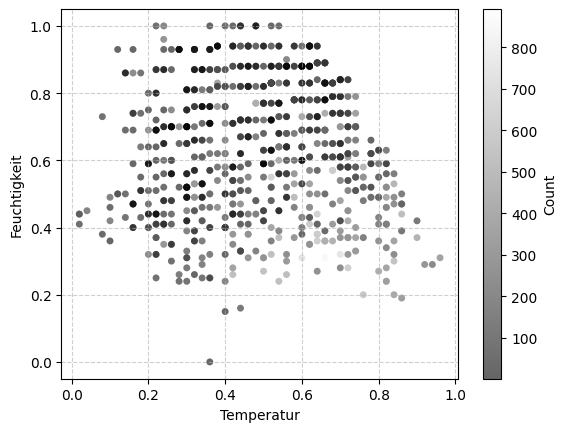

In [11]:
scatter = plt.scatter(
    df_sample['temp'],
    df_sample['hum'],
    c=df_sample['cnt'],
    cmap='grey',
    alpha=0.6,
    edgecolors='none',
    s=25
)
plt.grid(True,
         linestyle='--',
         alpha=0.6
         )
plt.xlabel("Temperatur")
plt.ylabel("Feuchtigkeit")
plt.colorbar(scatter,
             label='Count')

#### Interpretation
Im Scatterplot lässt sich erkennen, dass mittlerer bis hoher Temperatur zwischen 0,4 und 0,8 sowie niedrige bis mittlere Luftfeuchtigkeit, respektive Werte zwischen 0,2 und 0,6 für hohe Ausleihzahlen, d.h. helle Farben, sorgen. Bei Luftfeuchtigkeit von über 0,8 fallen die Ausleihezahlen unabhängig der Temperatur. Kälte, also Temperaturen und 0,3 und hoher Luftfeuchtigkeit führen zu niedrigen Ausleihzahlen. Außerdem sind bei hohen Temperaturen und hoher luftfeuchtigkeit sowie niedrigen Temperaturen und niedriger Luftfeuchtigkeit in der Auswahl der Datensätze keine Ausleihen zu erkennen.

### Flottenauslastung pro Stunden

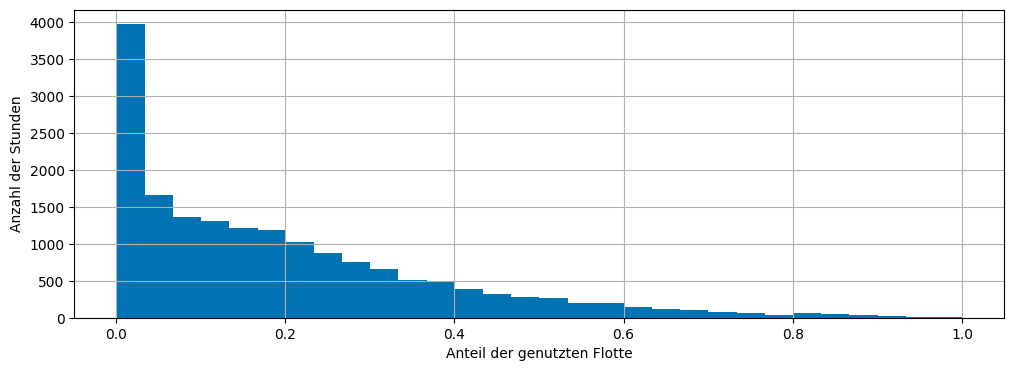

In [12]:
y = df["cnt"] / df["cnt"].max()
fig, ax = plt.subplots(figsize=(12, 4))
y.hist(bins=30, ax=ax)
_ = ax.set(
    xlabel="Anteil der genutzten Flotte",
    ylabel="Anzahl der Stunden",
)

#### Interpretation
Das Histogramm zeigt eine stark rechtsschiefe Verteilung, d.h. in etwa 40% aller Stunden hat das System weniger als 10% der maximalen Kapazität also, ungefähr 977 Räder, ausgeliehen. Außerdem sind in über 60% der Stunden unter 20% des Systems ausgelastet. Der Median liegt bei ungefähr 14,5% des Maximums. Das bedeutet, das System ist die meiste Zeit weit unter Vollauslastung, die Spitzennachfrage ist sehr selten und konzentriert sich auf wenige Stunden. Zieht man die Zahlen aus vorherigen Diagrammen in Betracht, kann man die Behauptung aufstellen, dass sich die hohe Auslastung auf den Geschäftsverkehr unter der Woche zurückführen lässt.


## Zusammenfassung